# Task 1: Article-Type Classification

## 1. Introduction

Identify the type of fashion item, such as a T-shirt, dress, handbag or shoe. The large number of rare categories makes class-level performance an important part of evaluation.

We compare four approaches: **Shallow MLP (baseline)**, **Deeper MLP**, **CNN**, and **HOG + HSV logistic regression**. The two MLPs are fully connected artificial neural networks. The CNN learns spatial features, while logistic regression learns from fixed shape and colour descriptors. All neural networks train from scratch.

The workflow covers data exploration, preprocessing, dedicated model-training sections, validation comparison, selection, and final evaluation. Run All trains missing candidates or reuses completed candidates with matching experiment fingerprints. Selected prediction checkpoints are written to `models/`, training tables to `results/`, reusable candidate checkpoints to `.cache/training/`, and figures to `figures/`.

## 2. Library Imports and Setup

In [1]:
from pathlib import Path
import json, sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from scripts.utils.model_comparison import run_comparison, validation_views
from scripts.preprocessing import task_frame, SEED
from scripts.utils.evaluation import evaluate_saved_checkpoint, calibration_table, support_band_metrics
TARGETS = ['articleType']
OUTPUT = ROOT / 'models'
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
def stem_for(target):
    return 'article_type' if target == 'articleType' else target

from app.server.utils.modeling import FashionMLP, SimpleCNN, TunedCNN
from scripts.preprocessing import IMAGE_SIZE, NORMALISATION_PATH, select_torch_device
DEVICE = select_torch_device()
torch.set_num_threads(4)

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


## 3. Load the Dataset and Frozen Splits

Use the product-group split established in Task 0. No upsampling is performed before splitting. Half of validation groups are used for model and epoch selection, one quarter for temperature fitting, and one quarter for checking calibration and choosing review thresholds. The internal test has prior development exposure; it is used only after model selection in this experiment.

In [2]:
frames = {}
for target in TARGETS:
    train = task_frame(target, 'train')
    selection, calibration, policy = validation_views(task_frame(target, 'validation'))
    frames[target] = dict(train=train, selection=selection, calibration=calibration, policy=policy)
    groups = [set(frame.group_key) for frame in frames[target].values()]
    assert all(left.isdisjoint(right) for i, left in enumerate(groups) for right in groups[i+1:])
    display(pd.Series({name: len(frame) for name, frame in frames[target].items()}, name=target))

train          27051
selection       2900
calibration     1378
policy          1564
Name: articleType, dtype: int64

## 4. Exploratory Data Analysis

Inspect training support before interpreting accuracy or macro-F1. Macro-F1 gives each supported class equal weight; accuracy gives each image equal weight. Literal `NA` remains a valid catalogue class where present; only genuinely blank target labels are excluded.

train               27051
selection            2900
calibration          1378
policy               1564
classes               124
classes_below_10       42
Name: articleType, dtype: int64

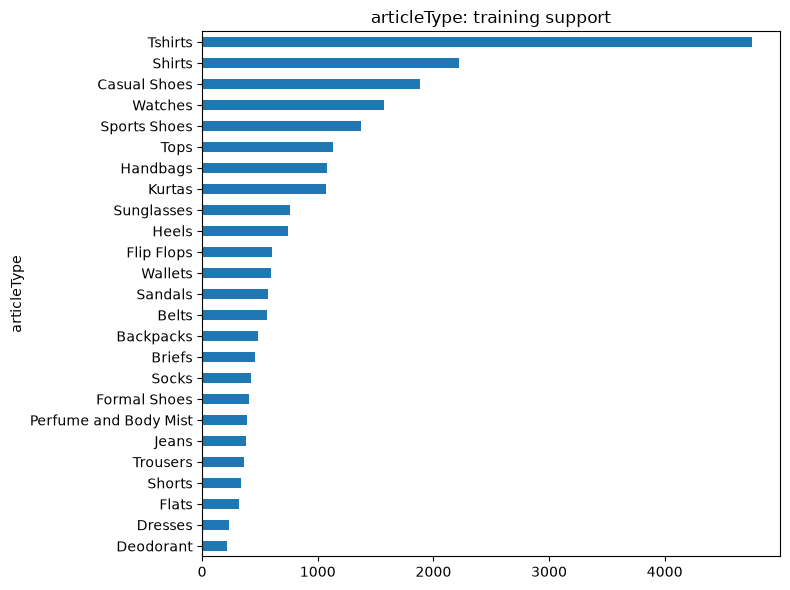

In [3]:
for target in TARGETS:
    train = task_frame(target, 'train')
    validation = task_frame(target, 'validation')
    selection, calibration, policy = validation_views(validation)
    counts = train[target].value_counts()
    display(pd.Series({'train': len(train), 'selection': len(selection),
                       'calibration': len(calibration), 'policy': len(policy),
                       'classes': len(counts), 'classes_below_10': int((counts < 10).sum())}, name=target))
    counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f'{target}: training support')
    plt.tight_layout()
    plt.show()

## 5. Image Preprocessing and Training Protocol

All neural models receive 96 x 128 RGB images resized with bilinear interpolation and normalized using frozen training statistics. Training images receive random horizontal flips; evaluation is deterministic. Deterministic resized pixels are cached in RAM only to avoid repeated decoding.

The shared training loop uses Adam with initial learning rate 0.001, ordinary cross-entropy, batch size 64, and at most 30 epochs. It stops after seven epochs without improved validation macro-F1 and restores the best epoch. CUDA training uses mixed precision; validation and inference use float32. Native CUDA batch-normalization training kernels compute the same operation as the standard implementation and retain its checkpoint format.

The model sections below invoke training separately. Matching checkpoints are reused without changing their learned weights. The full implementations are in [classification.py](../scripts/utils/classification.py), [model_comparison.py](../scripts/utils/model_comparison.py), and [modeling.py](../app/server/utils/modeling.py).

In [4]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
display(pd.Series({'image_width': IMAGE_SIZE[0], 'image_height': IMAGE_SIZE[1],
                   'batch_size': 64, 'initial_learning_rate': 0.001,
                   'max_epochs': 30, 'early_stopping_patience': 7}))
normalisation

image_width                 96.000
image_height               128.000
batch_size                  64.000
initial_learning_rate        0.001
max_epochs                  30.000
early_stopping_patience      7.000
dtype: float64

{'mean': [0.8502750031713799, 0.8334922756826109, 0.8277549238925582],
 'std': [0.26589262549701936, 0.2775687167185324, 0.28121521485116663],
 'image_size': [96, 128]}

## 6. Shallow MLP (Baseline)

### 6.1 Architecture

Flatten -> Dense(256) -> ReLU -> Dropout(0.2) -> output logits.

This fully connected ANN has one hidden layer. It provides the baseline for testing whether additional hidden layers or convolution improve image classification. Flattening makes all pixel positions available to the dense layer but supplies no explicit local spatial structure.

In [5]:
for target in TARGETS:
    labels = sorted(frames[target]['train'][target].unique())
    model = FashionMLP(len(labels), deep=False)
    print(target, model)
    print('Parameters:', sum(p.numel() for p in model.parameters()))

articleType FashionMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=36864, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=124, bias=True)
  )
)
Parameters: 9469308


### 6.2 Train and Validate the Shallow MLP

In [6]:
shallow_results = {}
for target in TARGETS:
    shallow_results[target] = run_comparison(target, methods=['shallow_mlp'], finalize=False)
    display(shallow_results[target])

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


articleType: resume shallow_mlp


     method  validation_accuracy  validation_macro_f1
shallow_mlp             0.692069             0.332388


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
shallow_mlp,shallow_mlp,0.692069,0.332388,0.036554,9469308,30,True


## 7. Deeper MLP

### 7.1 Architecture

Flatten -> Dense(256) -> Dense(128) -> Dense(64) -> output logits, with ReLU and Dropout(0.2) after each hidden layer.

The deeper MLP has three hidden layers. It retains the baseline first-layer width and training settings while adding two nonlinear hidden layers. Greater depth is a hypothesis to evaluate, not a guarantee of improvement.

In [7]:
for target in TARGETS:
    labels = sorted(frames[target]['train'][target].unique())
    model = FashionMLP(len(labels), deep=True)
    print(target, model)
    print('Parameters:', sum(p.numel() for p in model.parameters()))

articleType FashionMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=36864, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.2, inplace=False)
    (10): Linear(in_features=64, out_features=124, bias=True)
  )
)
Parameters: 9486652


### 7.2 Train and Validate the Deeper MLP

In [8]:
deeper_results = {}
for target in TARGETS:
    deeper_results[target] = run_comparison(target, methods=['deeper_mlp'], finalize=False)
    display(deeper_results[target])

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


articleType: resume deeper_mlp


    method  validation_accuracy  validation_macro_f1
deeper_mlp             0.727241             0.368688


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
deeper_mlp,deeper_mlp,0.727241,0.368688,0.015929,9486652,30,True


## 8. Convolutional Neural Network (CNN)

### 8.1 Architecture and Tuning Design

| Configuration | Convolution blocks | Classification head | Learning-rate schedule |
|---|---|---|---|
| Ordinary CNN | 32 -> 64 -> 128 | Adaptive pool 2x2 -> Dense 128 | None |
| Scheduled CNN | 32 -> 64 -> 128 | Adaptive pool 2x2 -> Dense 128 | ReduceLROnPlateau |
| Four-block scheduled CNN | 32 -> 64 -> 128 -> 256 | Adaptive pool 2x2 -> Dense 256 | ReduceLROnPlateau |

Each block contains a 3x3 convolution, batch normalization, ReLU, and 2x2 max pooling. The head uses ReLU and Dropout(0.2). The four-block configuration is inspired by the rice sample, while retaining our input resolution and pooled head.

The scheduled three-block run isolates the addition of the scheduler. The larger configuration changes both the convolution stack and dense head. All three use the same selection images; the CNN entry in the final four-model table is the best CNN configuration by validation macro-F1, then accuracy, then fewer parameters.

In [9]:
for target in TARGETS:
    labels = sorted(frames[target]['train'][target].unique())
    for architecture in (SimpleCNN, TunedCNN):
        model = architecture(len(labels))
        print(target, model)
        print('Parameters:', sum(p.numel() for p in model.parameters()))

articleType SimpleCNN(
  (layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): TrainingBatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): TrainingBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): TrainingBatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(2, 2))
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=512, out_featu

### 8.2 Train and Validate CNN Configurations

In [10]:
cnn_results = {}
for target in TARGETS:
    cnn_results[target] = run_comparison(target, methods=['cnn_ordinary', 'cnn_scheduled',
                                                       'cnn_four_blocks_scheduled'], finalize=False)
    display(cnn_results[target])

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


articleType: resume cnn_ordinary


      method  validation_accuracy  validation_macro_f1
cnn_ordinary             0.821379             0.578026


articleType: resume cnn_scheduled


       method  validation_accuracy  validation_macro_f1
 cnn_ordinary             0.821379             0.578026
cnn_scheduled             0.831379             0.598380


articleType: resume cnn_four_blocks_scheduled


                   method  validation_accuracy  validation_macro_f1
             cnn_ordinary             0.821379             0.578026
            cnn_scheduled             0.831379             0.598380
cnn_four_blocks_scheduled             0.869655             0.671979


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
cnn_ordinary,simple_cnn,0.821379,0.578026,0.010436,175356,30,True
cnn_scheduled,simple_cnn,0.831379,0.598380,0.011574,175356,30,True
cnn_four_blocks_scheduled,tuned_cnn,0.869655,0.671979,0.047496,683644,30,True


## 9. HOG + HSV Logistic Regression

### 9.1 Feature Extraction and Model

HOG describes local edge orientations and shape; HSV histograms describe colour. These fixed descriptors are standardized using the training set, then passed to logistic regression with C=1, balanced class weights, the L-BFGS solver, and at most 1,500 iterations. This model provides a traditional machine-learning comparison with the neural models. It has no epoch-based neural learning curve.

### 9.2 Train and Validate Logistic Regression

In [11]:
linear_results = {}
for target in TARGETS:
    linear_results[target] = run_comparison(target, methods=['hog_hsv_logistic_regression'], finalize=False)
    display(linear_results[target])

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


articleType: resume hog_hsv_logistic_regression


                     method  validation_accuracy  validation_macro_f1
hog_hsv_logistic_regression             0.791034             0.614257


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.791034,0.614257,0.113435,159340,0,True


## 10. Model Comparison and Selection

Compare the four model families in the same order: Shallow MLP baseline, Deeper MLP, CNN, and HOG + HSV logistic regression. Select by validation macro-F1, breaking ties with accuracy and then fewer parameters. The following cell resumes the completed candidates, saves the comparison, calibrates the winner on separate validation groups, and evaluates the frozen winner on the internal test. No fixed recipe replaces the selected model.

CNN tuning results retain all three configurations and show accuracy changes in absolute proportions (multiply by 100 for percentage points). These selection-view values are not directly comparable to historical full-validation tables.

In [12]:
comparisons, tuning = {}, {}
for target in TARGETS:
    comparisons[target], tuning[target] = run_comparison(target)
    print(target, ': four-model comparison')
    display(comparisons[target])
    print('CNN tuning: changes relative to the ordinary CNN on the same selection images')
    display(tuning[target])

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


articleType: resume shallow_mlp


     method  validation_accuracy  validation_macro_f1
shallow_mlp             0.692069             0.332388


articleType: resume deeper_mlp


     method  validation_accuracy  validation_macro_f1
shallow_mlp             0.692069             0.332388
 deeper_mlp             0.727241             0.368688


...

D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


articleType : four-model comparison


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection,family,selected
method,,,,,,,,,
shallow_mlp,shallow_mlp,0.692069,0.332388,0.036554,9469308,30,True,shallow_mlp,False
deeper_mlp,deeper_mlp,0.727241,0.368688,0.015929,9486652,30,True,deeper_mlp,False
cnn_four_blocks_scheduled,tuned_cnn,0.869655,0.671979,0.047496,683644,30,True,cnn,True
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.791034,0.614257,0.113435,159340,0,True,hog_hsv,False


CNN tuning: changes relative to the ordinary CNN on the same selection images


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,,,
cnn_ordinary,simple_cnn,0.821379,0.578026,0.010436,175356,30,True,0.000000,0.000000
cnn_scheduled,simple_cnn,0.831379,0.598380,0.011574,175356,30,True,0.010000,0.020354
cnn_four_blocks_scheduled,tuned_cnn,0.869655,0.671979,0.047496,683644,30,True,0.048276,0.093953


## 11. Learning Curves

Compare validation accuracy and macro-F1 across epochs. Training metrics use augmented inputs and training-mode dropout, so the train-validation gap is descriptive rather than an identical-conditions comparison.

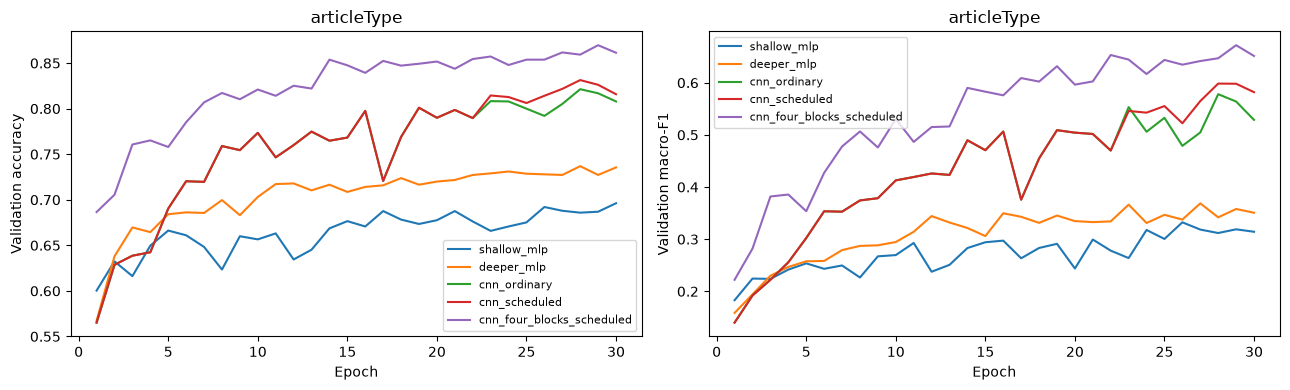

target                                                               articleType
selected                                               cnn_four_blocks_scheduled
cnn_selected                                           cnn_four_blocks_scheduled
highest_validation_accuracy                            cnn_four_blocks_scheduled
test_metrics                   {'accuracy': 0.8700594613501225, 'macro_f1': 0...
run_signature                  f875e04651dc66e6a69d510280bb86de40c60c80c2373b...
split_sizes                    {'train': 27051, 'selection': 2900, 'calibrati...
test_scope                         internal_test_with_prior_development_exposure
dtype: object

In [13]:
for target in TARGETS:
    directory = RESULTS
    stem = stem_for(target)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for method in ['shallow_mlp', 'deeper_mlp', 'cnn_ordinary', 'cnn_scheduled', 'cnn_four_blocks_scheduled']:
        history = pd.read_csv(directory / f'{stem}_{method}_history.csv')
        axes[0].plot(history.epoch, history.validation_accuracy, label=method)
        axes[1].plot(history.epoch, history.validation_macro_f1, label=method)
    for ax, metric in zip(axes, ['accuracy', 'macro-F1']):
        ax.set(xlabel='Epoch', ylabel=f'Validation {metric}', title=target)
        ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / f'{stem}_learning_curves.png', dpi=160)
    plt.show()
    display(pd.Series(json.loads((directory / f'{stem}_summary.json').read_text())))

## 12. Selected-Model Evaluation and Error Analysis

### 12.1 Internal-Test Metrics

The internal test has prior development exposure and does not provide an independent real-world estimate. Its results do not select models or hyperparameters in this experiment. Check supported-class F1, calibration, and training-support bands alongside accuracy.

In [14]:
test_results = {}
for target in TARGETS:
    directory = RESULTS
    stem = stem_for(target)
    result = evaluate_saved_checkpoint(OUTPUT / f'{stem}_model.pt', task_frame(target, 'test'),
                                       device='cuda' if torch.cuda.is_available() else 'cpu')
    test_results[target] = result
    display(pd.Series(result['metrics'], name=target))
    supported = np.unique(result['truth'])
    print(classification_report(result['truth'], result['predictions'], labels=supported,
          target_names=[result['labels'][i] for i in supported], zero_division=0))
    display(calibration_table(result['truth'], result['probabilities']))
    display(support_band_metrics(np.asarray(result['labels'])[result['truth']],
                                np.asarray(result['labels'])[result['predictions']],
                                task_frame(target, 'train')[target].value_counts()))

accuracy    0.870059
macro_f1    0.633469
ece         0.015864
nll         0.436404
brier       0.191733
Name: articleType, dtype: float64

                       precision    recall  f1-score   support

   Accessory Gift Set       0.95      1.00      0.97        18
            Backpacks       0.90      0.92      0.91       110
               Bangle       0.67      1.00      0.80         2
          Basketballs       0.00      0.00      0.00         1
                Belts       0.99      1.00      1.00       132
              Blazers       0.00      0.00      0.00         3
              Booties       0.50      1.00      0.67         2
               Boxers       1.00      0.40      0.57         5
                  Bra       1.00      0.94      0.97        31
             Bracelet       0.00      0.00      0.00         1
               Briefs       0.97      0.96      0.97       106
            Camisoles       0.00      0.00      0.00         1
               Capris       0.56      0.54      0.55        26
                 Caps       1.00      0.86      0.92        42
         Casual Shoes       0.83      0.86      0.84  

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",0.183278,0.625000,8
"(0.2, 0.3]",0.268620,0.266667,30
"(0.3, 0.4]",0.359404,0.361842,152
"(0.4, 0.5]",0.452913,0.495327,214
"(0.5, 0.6]",0.549751,0.586957,368
"(0.6, 0.7]",0.648942,0.660147,409
"(0.7, 0.8]",0.752211,0.793792,451
"(0.8, 0.9]",0.853030,0.913478,601


,test_images,evaluated_classes,macro_f1
support_band,,,
tail (<50),176,49,0.472059
medium (50-499),1586,38,0.745118
head (>=500),3956,14,0.895356


### 12.2 Confusion Matrices

For article type, display the twenty most frequent training classes plus an additional column containing all other predictions, so omitted classes do not hide errors during row normalization.

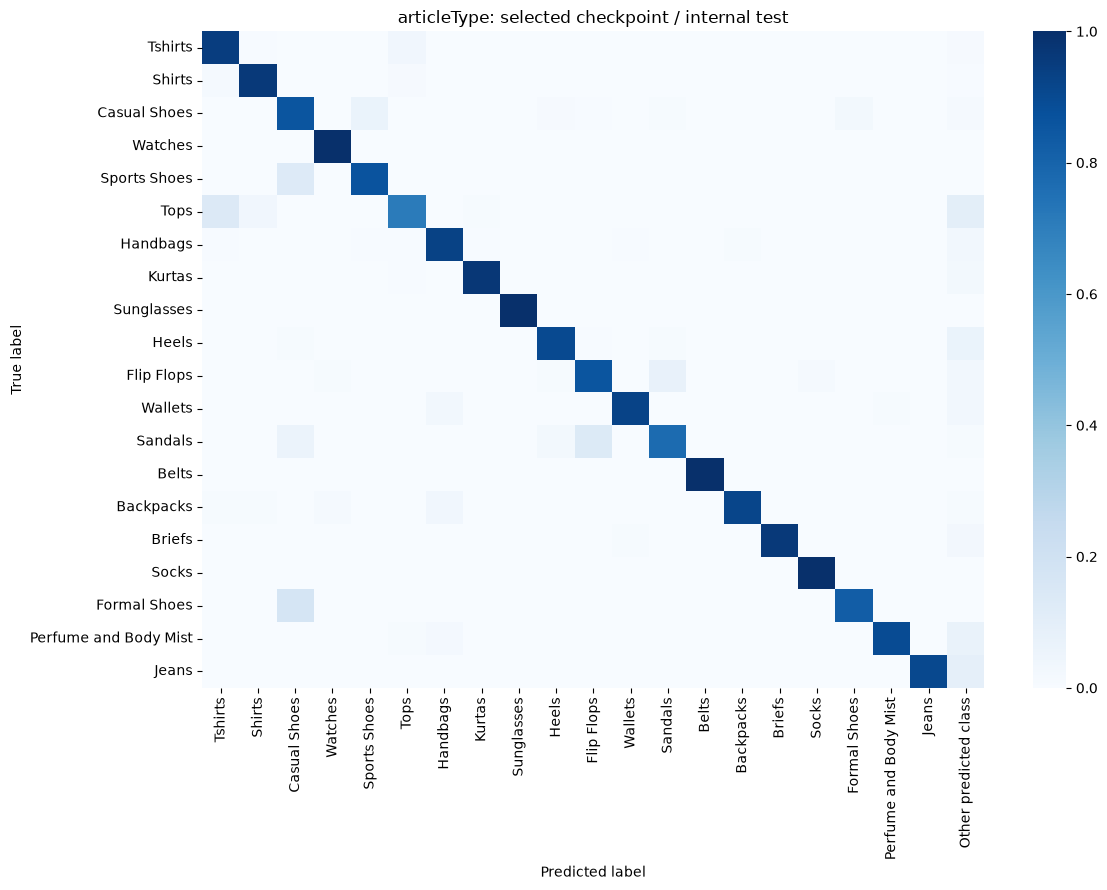

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
for target in TARGETS:
    directory = RESULTS
    stem = stem_for(target)
    result = test_results[target]
    labels = result['labels']
    if target == 'articleType':
        shown = task_frame(target, 'train')[target].value_counts().head(20).index.tolist()
        indices = [labels.index(label) for label in shown]
        others = [i for i in range(len(labels)) if i not in indices]
        matrix = confusion_matrix(result['truth'], result['predictions'], labels=np.arange(len(labels)))
        counts = np.column_stack([matrix[indices][:, indices], matrix[indices][:, others].sum(1)])
        normalized = counts / np.maximum(counts.sum(1, keepdims=True), 1)
        fig, ax = plt.subplots(figsize=(12, 9))
        sns.heatmap(normalized, xticklabels=shown + ['Other predicted class'], yticklabels=shown,
                    cmap='Blues', vmin=0, vmax=1, ax=ax)
        ax.set(xlabel='Predicted label', ylabel='True label')
    else:
        fig, ax = plt.subplots(figsize=(8, 7))
        ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'],
            labels=np.arange(len(labels)), display_labels=labels, normalize='true',
            values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{target}: selected checkpoint / internal test')
    fig.tight_layout()
    fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
    plt.show()

## 13. Saved Model and Prediction Example

The calibrated selected checkpoint is saved under `models/<target>_model.pt`. It uses the same inference interface as the web application. Each completed comparison replaces the corresponding checkpoint used by the application. Restart the backend to load the replacement.

In [16]:
from PIL import Image
from app.server.utils.classifier import FashionClassifier
for target in TARGETS:
    path = OUTPUT / f'{stem_for(target)}_model.pt'
    predictor = FashionClassifier(path, device='cpu')
    with Image.open(frames[target]['selection'].image_path.iloc[0]) as image:
        print(target, predictor.predict(image))

articleType {'target': 'articleType', 'label': 'Sports Shoes', 'confidence': 0.9475778791200019, 'top_k': [{'label': 'Sports Shoes', 'confidence': 0.9475778791200019}, {'label': 'Casual Shoes', 'confidence': 0.050230547001758295}, {'label': 'Pendant', 'confidence': 0.0006985499748822783}], 'needs_review': False, 'review_threshold': 0.5, 'confidence_calibrated': True}


## 14. Ultimate Judgement and Conclusion

Use the measured table below to state which model was selected, how it compares with the shallow baseline, and whether CNN tuning improved accuracy and macro-F1. Improvement is measured on this frozen split and does not imply superiority over results from a different dataset. Visual search is evaluated separately in Task 4.

In [17]:
for target in TARGETS:
    comparison = comparisons[target]
    winner = comparison.loc[comparison.selected].iloc[0]
    baseline = comparison.loc['shallow_mlp']
    display(pd.Series({'selected_method': winner.name,
                       'validation_accuracy': winner.validation_accuracy,
                       'validation_macro_f1': winner.validation_macro_f1,
                       'accuracy_gain_vs_shallow_pp': 100 * (winner.validation_accuracy - baseline.validation_accuracy),
                       'macro_f1_gain_vs_shallow': winner.validation_macro_f1 - baseline.validation_macro_f1}, name=target))

selected_method                cnn_four_blocks_scheduled
validation_accuracy                             0.869655
validation_macro_f1                             0.671979
accuracy_gain_vs_shallow_pp                    17.758621
macro_f1_gain_vs_shallow                         0.33959
Name: articleType, dtype: object

## 15. Independent Literature Comparison

Ziwei Liu, Ping Luo, Shi Qiu, Xiaogang Wang and Xiaoou Tang (2016). [DeepFashion: Powering Robust Clothes Recognition and Retrieval with Rich Annotations](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Liu_DeepFashion_Powering_Robust_CVPR_2016_paper.pdf). *CVPR*, pp. 1096–1104.

DeepFashion addresses the related goal of clothing category recognition. FashionNet combines global features with clothing landmarks and attribute supervision. The paper reports 82.58% category top-3 accuracy (Table 2). Its 50-category benchmark, additional supervision, large-scale pretraining/fine-tuning protocol and shop/consumer imagery differ from our 124-category private catalogue, frozen product-group split and models trained only on the supplied training rows. Our measured top-3 accuracy therefore does not establish superiority; neither top-3 score is directly comparable to our primary macro F1. The methodological lesson is that localized garment information can help recognition, while our experiment only establishes the relative performance of the candidates on this dataset. No paper weights or images were imported.

Historical numerical comparisons in this literature discussion are not results of the new MLP/CNN experiment; use the executed tables above.